In [1]:
import torch 
from torch import nn, Tensor

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [3]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2)

In [32]:
flow = Flow()

optimizer = torch.optim.Adam(flow.parameters(), 1e-3)
loss_fn = nn.MSELoss()

for epoch in range(60000):
    x_1 = Tensor(make_moons(256, noise=0.05)[0])
    epsilon = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    t = torch.clamp(t, min=1e-5, max=1.0-1e-5)
    
    x_t = torch.sqrt(t) * x_1 + torch.sqrt(1-t) * epsilon

    mu_t = torch.sqrt(t) * x_1
    mu_t_prime = 0.5 / torch.sqrt(t) * x_1
    sigma_t = torch.sqrt(1-t)
    sigma_t_prime = -0.5 / torch.sqrt(1-t)

    dx_t = sigma_t_prime / sigma_t * (x_t - mu_t) + mu_t_prime
    
    optimizer.zero_grad()
    loss = loss_fn(flow(t=t, x_t=x_t), dx_t)
    if epoch % 5000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')
    loss.backward()
    optimizer.step()

Epoch 0, Loss: 3.276311159133911
Epoch 5000, Loss: 2.1208341121673584
Epoch 10000, Loss: 2.962597370147705
Epoch 15000, Loss: 1.42779541015625
Epoch 20000, Loss: 1.5298728942871094
Epoch 25000, Loss: 2.371955156326294
Epoch 30000, Loss: 2.162450075149536
Epoch 35000, Loss: 2.3351690769195557
Epoch 40000, Loss: 2.0455427169799805
Epoch 45000, Loss: 2.735653877258301
Epoch 50000, Loss: 1.8881103992462158
Epoch 55000, Loss: 1.5070878267288208


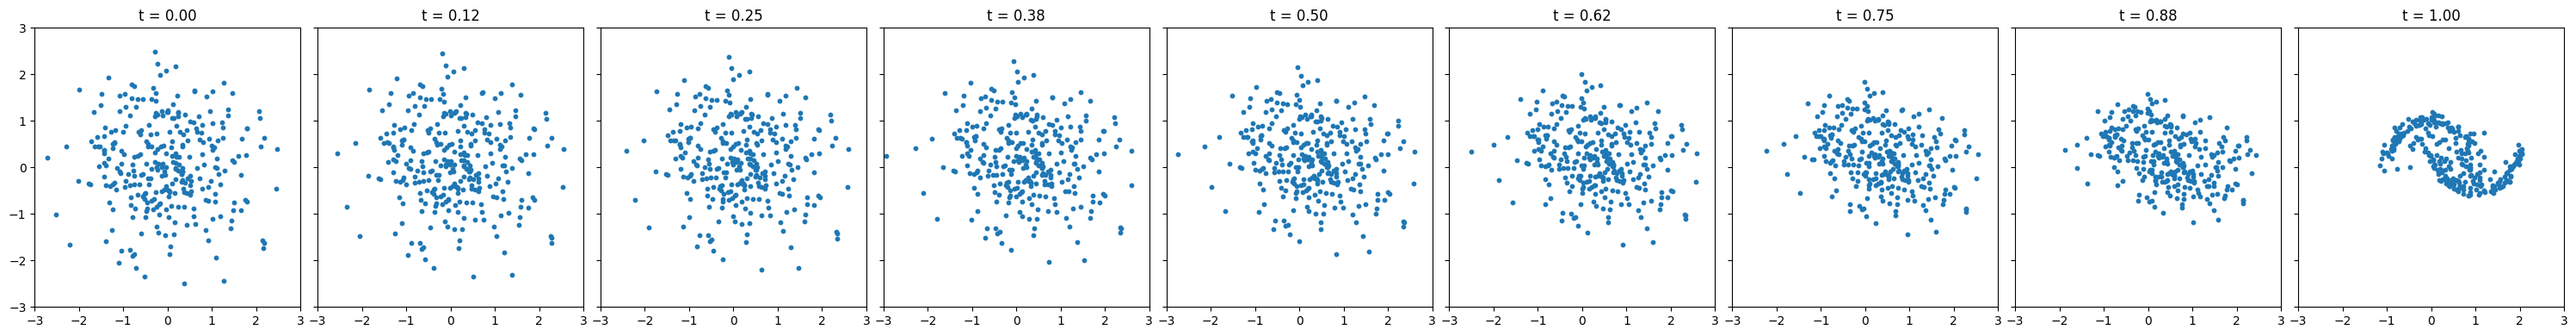

In [33]:
x = torch.randn(300, 2)
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0.0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()